1. Data Loading

In [1]:
import pandas as pd
df = pd.read_csv("../data/raw/netflix_titles.csv", encoding='Latin1')
print(df.head())
print(df.info())
print(df.isna().sum())

  show_id     type                  title         director  \
0      s1    Movie   Dick Johnson Is Dead  Kirsten Johnson   
1      s2  TV Show          Blood & Water              NaN   
2      s3  TV Show              Ganglands  Julien Leclercq   
3      s4  TV Show  Jailbirds New Orleans              NaN   
4      s5  TV Show           Kota Factory              NaN   

                                                cast        country  \
0                                                NaN  United States   
1  Ama Qamata, Khosi Ngema, Gail Mabalane, Thaban...   South Africa   
2  Sami Bouajila, Tracy Gotoas, Samuel Jouy, Nabi...            NaN   
3                                                NaN            NaN   
4  Mayur More, Jitendra Kumar, Ranjan Raj, Alam K...          India   

           date_added  release_year rating   duration  ... Unnamed: 16  \
0  September 25, 2021          2020  PG-13     90 min  ...         NaN   
1  September 24, 2021          2021  TV-MA  2 Season

2. Initial Inspection

In [2]:
#2.2    Inspecting columns formally
print(df.director.isna().sum())
print(df.title.isna().sum())
print(df.director.dtype)
print(df.date_added.dtype)
print(df.country.isna().sum())

2634
0
str
str
831


In [3]:
#2.3    Inspecting "country" column
print(df['country'].nunique())
print(df['country'].str.len() > 50)
bad_rows_all = df[
    df['country'].isna() |
    (df['country'].str.strip() == '') |
    (~df['country'].str.match(r'^[A-Za-z\s,]+$', na=False)) |
    df['country'].str.len() > 50
]
print(bad_rows_all[['show_id', 'country']])
print(df['country'].isna().sum())

748
0       False
1       False
2       False
3       False
4       False
        ...  
8804    False
8805    False
8806    False
8807    False
8808    False
Name: country, Length: 8809, dtype: bool
Empty DataFrame
Columns: [show_id, country]
Index: []
831


In [4]:
#2.4    Inspecting "director" column
print(df.director.isna().sum())
print(df.director.nunique())
print(df.director.duplicated().sum())
print(df['director'].value_counts().head(20))

2634
4529
4279
director
Rajiv Chilaka              19
RaÃºl Campos, Jan Suter    18
Suhas Kadav                16
Marcus Raboy               16
Jay Karas                  14
Cathy Garcia-Molina        13
Youssef Chahine            12
Martin Scorsese            12
Jay Chapman                12
Steven Spielberg           11
Don Michael Paul           10
David Dhawan                9
Quentin Tarantino           8
Robert Rodriguez            8
YÄ±lmaz ErdoÄan            8
Hakan AlgÃ¼l                8
Fernando AyllÃ³n            8
Troy Miller                 8
Kunle Afolayan              8
Ryan Polito                 8
Name: count, dtype: int64


In [5]:
#2.5    Inspecting "type", "title" and "show_id" 
print(df.type.unique())
print(df.title.nunique())
print(df.title.duplicated().sum())
print(df.show_id.nunique())

<StringArray>
['Movie', 'TV Show']
Length: 2, dtype: str
8806
3
8809


In [6]:
#2.6    Inspecting "cast" column
print(df['cast'].isna().sum())
print(df['cast'].dropna().head())

825
1    Ama Qamata, Khosi Ngema, Gail Mabalane, Thaban...
2    Sami Bouajila, Tracy Gotoas, Samuel Jouy, Nabi...
4    Mayur More, Jitendra Kumar, Ranjan Raj, Alam K...
5    Kate Siegel, Zach Gilford, Hamish Linklater, H...
6    Vanessa Hudgens, Kimiko Glenn, James Marsden, ...
Name: cast, dtype: str


In [7]:
#2.7    Inspecting "release_year" column
print(df['release_year'].isna().sum())
print(df.groupby('release_year')['release_year'].count().tail(20))
print(df.groupby('release_year')['release_year'].count().max())
print(sorted(df['release_year'].unique()[-10:]))

0
release_year
2003      61
2004      64
2005      80
2006      96
2007      88
2008     136
2009     152
2010     194
2011     185
2012     237
2013     288
2014     353
2015     560
2016     902
2017    1032
2018    1147
2019    1030
2020     953
2021     592
2024       1
Name: release_year, dtype: int64
1147
[np.int64(1942), np.int64(1943), np.int64(1944), np.int64(1946), np.int64(1947), np.int64(1955), np.int64(1965), np.int64(1967), np.int64(1968), np.int64(2024)]


In [8]:
#2.8    Inspecting "date_added" column
print(df['date_added'])
print(df['date_added'].isna().sum())
df['date_added'] = pd.to_datetime(df['date_added'], errors='coerce')
df['year_added'] = df['date_added'].dt.year
df['month_added'] = df['date_added'].dt.month
print(df[['date_added', 'year_added', 'month_added']])
print(df['month_added'].isna().sum())
print(df['year_added'].isna().sum())
print(df['date_added'].isna().sum())

0       September 25, 2021
1       September 24, 2021
2       September 24, 2021
3       September 24, 2021
4       September 24, 2021
               ...        
8804      November 1, 2019
8805      January 11, 2020
8806         March 2, 2019
8807         April 5, 2024
8808         April 5, 2024
Name: date_added, Length: 8809, dtype: str
10
     date_added  year_added  month_added
0    2021-09-25      2021.0          9.0
1    2021-09-24      2021.0          9.0
2    2021-09-24      2021.0          9.0
3    2021-09-24      2021.0          9.0
4    2021-09-24      2021.0          9.0
...         ...         ...          ...
8804 2019-11-01      2019.0         11.0
8805 2020-01-11      2020.0          1.0
8806 2019-03-02      2019.0          3.0
8807 2024-04-05      2024.0          4.0
8808 2024-04-05      2024.0          4.0

[8809 rows x 3 columns]
98
98
98


In [9]:
#2.9    Inspecting "listed_in" column
print(df['listed_in'].head(10))
print(df['listed_in'].isna().sum())
print(df['listed_in'].nunique())
print(df['listed_in'].value_counts().head(10))

0                                        Documentaries
1      International TV Shows, TV Dramas, TV Mysteries
2    Crime TV Shows, International TV Shows, TV Act...
3                               Docuseries, Reality TV
4    International TV Shows, Romantic TV Shows, TV ...
5                   TV Dramas, TV Horror, TV Mysteries
6                             Children & Family Movies
7     Dramas, Independent Movies, International Movies
8                         British TV Shows, Reality TV
9                                     Comedies, Dramas
Name: listed_in, dtype: str
0
516
listed_in
Dramas, International Movies                        362
Documentaries                                       359
Stand-Up Comedy                                     334
Comedies, Dramas, International Movies              274
Dramas, Independent Movies, International Movies    252
Kids' TV                                            220
Children & Family Movies                            215
Children & Fam

In [10]:
#2.9.1  Inspecting "listed_in" column
genres = (
    df['listed_in']
    .str.split(',')
    .explode()
    .str.strip()
)

print(genres.value_counts().head(15))

listed_in
International Movies        2752
Dramas                      2427
Comedies                    1674
International TV Shows      1351
Documentaries                869
Action & Adventure           859
TV Dramas                    763
Independent Movies           756
Children & Family Movies     641
Romantic Movies              616
TV Comedies                  581
Thrillers                    577
Crime TV Shows               470
Kids' TV                     451
Docuseries                   395
Name: count, dtype: int64


In [11]:
#2.10   Inspecting "duration" Column
print(df['duration'].value_counts().head(10))
print(df['duration'].isna().sum())
print(df['duration'].nunique())
print(df.groupby('type')['duration'].head(5))
print(df['duration'].str.contains('Season', 'Seasons').value_counts())

duration
1 Season     1794
2 Seasons     425
3 Seasons     199
90 min        152
94 min        146
97 min        146
93 min        146
91 min        144
95 min        137
96 min        130
Name: count, dtype: int64
3
220
0        90 min
1     2 Seasons
2      1 Season
3      1 Season
4     2 Seasons
5      1 Season
6        91 min
7       125 min
9       104 min
12      127 min
Name: duration, dtype: str
duration
False    6132
True     2677
Name: count, dtype: int64


In [12]:
#2.10.1     Inspecting "duration" column
print(df['type'].value_counts())
df['duration'] = df['duration'].astype(str)
df['duration_num'] = (
    df['duration']
    .str.extract(r'(\d+)', expand=False)
)
print(df[['duration', 'duration_num']].head(10))

type
Movie      6132
TV Show    2677
Name: count, dtype: int64
    duration duration_num
0     90 min           90
1  2 Seasons            2
2   1 Season            1
3   1 Season            1
4  2 Seasons            2
5   1 Season            1
6     91 min           91
7    125 min          125
8  9 Seasons            9
9    104 min          104


In [13]:
#2.11   Inspecting "rating" column
print(df['rating'].isna().sum())
print(df['rating'].unique())
print(df['rating'].nunique())
print(df['rating'].value_counts().head(18))
print(df['description'].isna().sum())

4
<StringArray>
[   'PG-13',    'TV-MA',       'PG',    'TV-14',    'TV-PG',     'TV-Y',
    'TV-Y7',        'R',     'TV-G',        'G',    'NC-17',   '74 min',
   '84 min',   '66 min',       'NR',        nan, 'TV-Y7-FV',       'UR',
        'A']
Length: 19, dtype: str
18
rating
TV-MA       3208
TV-14       2160
TV-PG        863
R            799
PG-13        490
TV-Y7        334
TV-Y         307
PG           287
TV-G         220
NR            80
G             41
TV-Y7-FV       6
NC-17          3
UR             3
74 min         1
84 min         1
66 min         1
A              1
Name: count, dtype: int64
0


3. Data Cleaning

In [14]:
#3.1    Removing Structural Issues
print(df.columns)
df = df.loc[:, ~df.columns.str.contains('^Unnamed')]
print(df.columns, df.shape)

Index(['show_id', 'type', 'title', 'director', 'cast', 'country', 'date_added',
       'release_year', 'rating', 'duration', 'listed_in', 'description',
       'Unnamed: 12', 'Unnamed: 13', 'Unnamed: 14', 'Unnamed: 15',
       'Unnamed: 16', 'Unnamed: 17', 'Unnamed: 18', 'Unnamed: 19',
       'Unnamed: 20', 'Unnamed: 21', 'Unnamed: 22', 'Unnamed: 23',
       'Unnamed: 24', 'Unnamed: 25', 'year_added', 'month_added',
       'duration_num'],
      dtype='str')
Index(['show_id', 'type', 'title', 'director', 'cast', 'country', 'date_added',
       'release_year', 'rating', 'duration', 'listed_in', 'description',
       'year_added', 'month_added', 'duration_num'],
      dtype='str') (8809, 15)


In [15]:
#3.2    Date Cleaning (Final Version)
#Step 1:    Convert "date_added"
df['date_added'] = pd.to_datetime(df['date_added'], errors='coerce')
#Step 2:    Extract "Year" & "Month"
date_index = df.columns.get_loc('date_added')
df.drop(columns=['year_added', 'month_added'], inplace=True)
df.insert(date_index+1, 'year_added', df['date_added'].dt.year)
df.insert(date_index+2, 'month_added', df['date_added'].dt.month)
print(df[['date_added', 'year_added', 'month_added']].head(10))
print(df[['date_added', 'year_added', 'month_added']].isna().sum())
print(df.columns)

  date_added  year_added  month_added
0 2021-09-25      2021.0          9.0
1 2021-09-24      2021.0          9.0
2 2021-09-24      2021.0          9.0
3 2021-09-24      2021.0          9.0
4 2021-09-24      2021.0          9.0
5 2021-09-24      2021.0          9.0
6 2021-09-24      2021.0          9.0
7 2021-09-24      2021.0          9.0
8 2021-09-24      2021.0          9.0
9 2021-09-24      2021.0          9.0
date_added     98
year_added     98
month_added    98
dtype: int64
Index(['show_id', 'type', 'title', 'director', 'cast', 'country', 'date_added',
       'year_added', 'month_added', 'release_year', 'rating', 'duration',
       'listed_in', 'description', 'duration_num'],
      dtype='str')


In [16]:
#3.3    Duration Cleaning (Fix type and separate "unit" from "value")

#Step 1: Extract numeric part safely
df['duration_value'] = pd.to_numeric(
    df['duration'].str.extract(r'(\d+)')[0],
    errors='coerce'
)

#Step 2: Assign unit from type column
df['duration_unit'] = df['type'].map({
    'Movie': 'minutes',
    'TV Show': 'seasons'
})

print(df[df['duration_value'].isna()])
print(df.loc[[5541, 5794, 5813], ['type', 'duration']])
df.drop(columns = ['duration_num', 'duration'], inplace=True)
print(df.columns)

#Step 3: Place 'duration_value' and 'duration_unit' next to 'title'
title_index = df.columns.get_loc('title')       #-- find position of title
duration_value_col = df.pop('duration_value')       #-- remove column 'duration_value'
duration_unit_col = df.pop('duration_unit')         #-- remove column 'duration_unit'
df.insert(title_index+1, 'duration_value', duration_value_col)      #-- insert 'duration_value' next to title
df.insert(title_index+2, 'duration_unit', duration_unit_col)        #-- insert 'duration_value' second next to tile
print(df.columns)

     show_id   type                                 title    director  \
5541   s5542  Movie                       Louis C.K. 2017  Louis C.K.   
5794   s5795  Movie                 Louis C.K.: Hilarious  Louis C.K.   
5813   s5814  Movie  Louis C.K.: Live at the Comedy Store  Louis C.K.   

            cast        country date_added  year_added  month_added  \
5541  Louis C.K.  United States 2017-04-04      2017.0          4.0   
5794  Louis C.K.  United States 2016-09-16      2016.0          9.0   
5813  Louis C.K.  United States 2016-08-15      2016.0          8.0   

      release_year  rating duration listed_in  \
5541          2017  74 min      NaN    Movies   
5794          2010  84 min      NaN    Movies   
5813          2015  66 min      NaN    Movies   

                                            description duration_num  \
5541  Louis C.K. muses on religion, eternal love, gi...          NaN   
5794  Emmy-winning comedy writer Louis C.K. brings h...          NaN   
5813  The

In [17]:
#3.4    "country" cleaning
print(df['country'].value_counts())
df['country'] = df['country'].str.strip()
df['country'] = df['country'].replace('', pd.NA)
print(df.country.isna().sum())
df['country'] = df['country'].fillna('Unknown')
print(df['country'].value_counts().head(10))
print(df['country'].isna().sum())
print(df['country'].str.contains('Unknown', na=False).sum())

country
United States                                    2819
India                                             972
United Kingdom                                    419
Japan                                             245
South Korea                                       200
                                                 ... 
Russia, Spain                                       1
Croatia, Slovenia, Serbia, Montenegro               1
Japan, Canada                                       1
United States, France, South Korea, Indonesia       1
United Arab Emirates, Jordan                        1
Name: count, Length: 748, dtype: int64
831
country
United States     2819
India              972
Unknown            831
United Kingdom     419
Japan              245
South Korea        200
Canada             181
Spain              145
France             124
Mexico             110
Name: count, dtype: int64
0
831


In [18]:
#3.5    "direcctor" cleaning

print(df['director'].isna().sum())
df['director'] = df['director'].str.strip()
df['director'] = df['director'].replace('', pd.NA)
print(df['director'].isna().sum())
df['director'] = df['director'].fillna('Unknown')
print(df['director'].str.contains('Unknown', na=False).sum())
print(df['director'].value_counts().head(10))
print(df[df['director'] == 'Unknown']['type'].value_counts())

2634
2634
2634
director
Unknown                    2634
Rajiv Chilaka                19
RaÃºl Campos, Jan Suter      18
Suhas Kadav                  16
Marcus Raboy                 16
Jay Karas                    14
Cathy Garcia-Molina          13
Youssef Chahine              12
Martin Scorsese              12
Jay Chapman                  12
Name: count, dtype: int64
type
TV Show    2446
Movie       188
Name: count, dtype: int64


In [19]:
#3.6    'listed_in' cleaning
df.rename(columns = {'listed_in': 'genres'}, inplace=True)
print(df.columns)
print(df['genres'].isna().sum())
df['genres'] = df['genres'].str.strip()
print(df['genres'].head(10))
print(df['genres'].value_counts().head(10))
print(df['genres'].str.contains('Dramas', na=False).sum())

Index(['show_id', 'type', 'title', 'duration_value', 'duration_unit',
       'director', 'cast', 'country', 'date_added', 'year_added',
       'month_added', 'release_year', 'rating', 'genres', 'description'],
      dtype='str')
0
0                                        Documentaries
1      International TV Shows, TV Dramas, TV Mysteries
2    Crime TV Shows, International TV Shows, TV Act...
3                               Docuseries, Reality TV
4    International TV Shows, Romantic TV Shows, TV ...
5                   TV Dramas, TV Horror, TV Mysteries
6                             Children & Family Movies
7     Dramas, Independent Movies, International Movies
8                         British TV Shows, Reality TV
9                                     Comedies, Dramas
Name: genres, dtype: str
genres
Dramas, International Movies                        362
Documentaries                                       359
Stand-Up Comedy                                     334
Comedies, Dramas, I

In [20]:
#3.7    "rating" cleaning
print(df['rating'].value_counts(dropna=False))
df['rating'].str.contains('min', na=False).value_counts().head(10)
df.loc[df['rating'].str.contains('min', na=False), 'rating'] = pd.NA
print(df['rating'].str.contains('min', na=False).value_counts())
print(df['rating'].isna().sum())
df['rating'] = df['rating'].fillna('Unknown')
print(df['rating'].isna().sum())

rating
TV-MA       3208
TV-14       2160
TV-PG        863
R            799
PG-13        490
TV-Y7        334
TV-Y         307
PG           287
TV-G         220
NR            80
G             41
TV-Y7-FV       6
NaN            4
NC-17          3
UR             3
74 min         1
84 min         1
66 min         1
A              1
Name: count, dtype: int64
rating
False    8809
Name: count, dtype: int64
7
0


In [21]:
#3.8    "cast" cleaning
print(df['cast'].isna().sum())
print(df['cast'].value_counts().head(10))
df['cast'] = df['cast'].fillna('Unknown')
print(df['cast'].str.contains('Unknown', na=False).value_counts())

825
cast
David Attenborough                                                                                                        19
Vatsal Dubey, Julie Tejwani, Rupa Bhimani, Jigna Bhardwaj, Rajesh Kava, Mousam, Swapnil                                   14
Samuel West                                                                                                               10
Jeff Dunham                                                                                                                7
David Spade, London Hughes, Fortune Feimster                                                                               6
Kevin Hart                                                                                                                 6
Michela Luci, Jamie Watson, Eric Peterson, Anna Claire Bartlam, Nicolas Aqui, Cory Doran, Julie Lemieux, Derek McGrath     6
Craig Sechler                                                                                                       

In [22]:
#3.9    'title' cleaning
print(df['title'].isna().sum())
print(df['title'].duplicated().value_counts().head(10))
df[df.duplicated(subset=['title'], keep=False)].sort_values('title')
df = df.drop_duplicates(subset = df.columns.difference(['show_id']))
print(df['title'].duplicated().value_counts())

0
title
False    8806
True        3
Name: count, dtype: int64
title
False    8806
Name: count, dtype: int64


In [23]:
#3.10   Quick checks (structure)
print(df.isna().sum())
print(df.duplicated().sum())

show_id            0
type               0
title              0
duration_value     3
duration_unit      0
director           0
cast               0
country            0
date_added        98
year_added        98
month_added       98
release_year       0
rating             0
genres             0
description        0
dtype: int64
0


In [24]:
#3.11   Structure fixes
df.loc[df['duration_value'].isna(), 'duration_unit'] = pd.NA
print(df[['duration_value', 'duration_unit']].isna().sum())
df['duration_value'] = df['duration_value'].astype('Int64')
df['year_added'] = df['year_added'].astype('Int64')
df['month_added'] = df['month_added'].astype('Int64')

duration_value    3
duration_unit     3
dtype: int64


4. 'date_added' Column Fix

In [25]:
#4.1    Final Date Cleaning (Handling multiple formats)
# Step 1: Import temporary dataframe for "date_added" inspection
df_temp = pd.read_csv("../data/raw/netflix_titles.csv", usecols = ['show_id', 'date_added'], encoding='Latin-1')
print(df_temp['date_added'].isna().sum())

# Step 2: Parse "date_added" with different formats
df_temp['date_added'] = pd.to_datetime(
    df_temp['date_added'].str.strip(),
    format='%B %d, %Y',
    errors='coerce'
)
print(df_temp['date_added'].isna().sum())
print(df_temp['date_added'].dropna().head(10))
print(df_temp['date_added'].dtype)

# Step 3: Merge parsed "date_added" back to main dataframe
df = df.drop(columns=['date_added'])
df = df.merge(df_temp, on='show_id', how='left')
df = df.drop(columns = ['year_added', 'month_added'])
print(df.info())


10
10
0   2021-09-25
1   2021-09-24
2   2021-09-24
3   2021-09-24
4   2021-09-24
5   2021-09-24
6   2021-09-24
7   2021-09-24
8   2021-09-24
9   2021-09-24
Name: date_added, dtype: datetime64[us]
datetime64[us]
<class 'pandas.DataFrame'>
RangeIndex: 8806 entries, 0 to 8805
Data columns (total 13 columns):
 #   Column          Non-Null Count  Dtype         
---  ------          --------------  -----         
 0   show_id         8806 non-null   str           
 1   type            8806 non-null   str           
 2   title           8806 non-null   str           
 3   duration_value  8803 non-null   Int64         
 4   duration_unit   8803 non-null   str           
 5   director        8806 non-null   str           
 6   cast            8806 non-null   str           
 7   country         8806 non-null   str           
 8   release_year    8806 non-null   int64         
 9   rating          8806 non-null   str           
 10  genres          8806 non-null   str           
 11  description 

In [26]:
#4.2 Fixing "date_added" position

# Step 1: Remove "date_added" from current position
col = df.pop('date_added')

# Step 2: Find and define new position
position = df.columns.get_loc('duration_unit') + 1

# Step 3: Insert "date_added" back to new position
df.insert(position, 'date_added', col)

print(df.columns)

Index(['show_id', 'type', 'title', 'duration_value', 'duration_unit',
       'date_added', 'director', 'cast', 'country', 'release_year', 'rating',
       'genres', 'description'],
      dtype='str')


In [27]:
# 4.3    Add 'year_added' and 'month_added' back based on cleaned "date_added"
df['year_added'] = df['date_added'].dt.year.astype('Int64')
df['month_added'] = df['date_added'].dt.month.astype('Int64')
print(df[['date_added', 'year_added', 'month_added']].head(10))
print(df[['date_added', 'year_added', 'month_added']].isna().sum())
print(df.info())

  date_added  year_added  month_added
0 2021-09-25        2021            9
1 2021-09-24        2021            9
2 2021-09-24        2021            9
3 2021-09-24        2021            9
4 2021-09-24        2021            9
5 2021-09-24        2021            9
6 2021-09-24        2021            9
7 2021-09-24        2021            9
8 2021-09-24        2021            9
9 2021-09-24        2021            9
date_added     10
year_added     10
month_added    10
dtype: int64
<class 'pandas.DataFrame'>
RangeIndex: 8806 entries, 0 to 8805
Data columns (total 15 columns):
 #   Column          Non-Null Count  Dtype         
---  ------          --------------  -----         
 0   show_id         8806 non-null   str           
 1   type            8806 non-null   str           
 2   title           8806 non-null   str           
 3   duration_value  8803 non-null   Int64         
 4   duration_unit   8803 non-null   str           
 5   date_added      8796 non-null   datetime64[us]
 6 

In [28]:
# 4.4 Define Positions of "year_added" and "month_added"
# Step 1: Remove "year_added" and "month_added" from current position
year_col = df.pop('year_added')
month_col = df.pop('month_added')

# Step 2: Find and define new position (after "date_added")
position = df.columns.get_loc('date_added') + 1

# Step 3: Insert "year_added" and "month_added" back to new position
df.insert(position, 'year_added', year_col)
df.insert(position + 1, 'month_added', month_col)

print(df.columns)

Index(['show_id', 'type', 'title', 'duration_value', 'duration_unit',
       'date_added', 'year_added', 'month_added', 'director', 'cast',
       'country', 'release_year', 'rating', 'genres', 'description'],
      dtype='str')


In [29]:
# 4.5 Final Quick Checks
print(df.info(), df.isna().sum())

<class 'pandas.DataFrame'>
RangeIndex: 8806 entries, 0 to 8805
Data columns (total 15 columns):
 #   Column          Non-Null Count  Dtype         
---  ------          --------------  -----         
 0   show_id         8806 non-null   str           
 1   type            8806 non-null   str           
 2   title           8806 non-null   str           
 3   duration_value  8803 non-null   Int64         
 4   duration_unit   8803 non-null   str           
 5   date_added      8796 non-null   datetime64[us]
 6   year_added      8796 non-null   Int64         
 7   month_added     8796 non-null   Int64         
 8   director        8806 non-null   str           
 9   cast            8806 non-null   str           
 10  country         8806 non-null   str           
 11  release_year    8806 non-null   int64         
 12  rating          8806 non-null   str           
 13  genres          8806 non-null   str           
 14  description     8806 non-null   str           
dtypes: Int64(3), da

In [30]:
# Save Cleaned File
df.to_csv("../data/processed/netflix_titles_cleaned_v1.csv", index=False)
df.to_pickle("../data/processed/netflix_titles_cleaned.pkl")

5. Analysis

In [31]:
# 5.1    Overview
print(df['type'].value_counts())
print(df['release_year'].min(), df['release_year'].max())
print(df['year_added'].min(), df['year_added'].max())
print(df['country'].unique())

type
Movie      6130
TV Show    2676
Name: count, dtype: int64
1925 2024
2008 2024
<StringArray>
[                                                        'United States',
                                                          'South Africa',
                                                               'Unknown',
                                                                 'India',
 'United States, Ghana, Burkina Faso, United Kingdom, Germany, Ethiopia',
                                                        'United Kingdom',
                                               'Germany, Czech Republic',
                                                                'Mexico',
                                                                'Turkey',
                                                             'Australia',
 ...
                        'Germany, United States, United Kingdom, Canada',
          'Canada, India, Thailand, United States, United Arab Emirates',
          

In [32]:
# 5.2.1    Content Distribution by Type and Year Added

type_counts = df['type'].value_counts()
type_percent = df['type'].value_counts(normalize=True) * 100        #-- percentage distribution of content types
print(type_counts, type_percent)
print(df.groupby(['year_added', 'type']).size().unstack())          #-- content added per year by type

pd.set_option('display.max_rows', None)
print(df.groupby(['release_year']).size().sort_index())      #-- content released per year
pd.reset_option('display.max_rows')
df['content_age_at_add'] = df['year_added'] - df['release_year']        #-- age of content at time of addition

print(df['content_age_at_add'].describe())              #-- distribution of content age at addition
print(df[df['content_age_at_add'] < 0][['title', 'release_year', 'year_added', 'content_age_at_add']])      #-- check for negative ages (data issues)
print(df[df['content_age_at_add'] < 0]['type'].value_counts())      #-- check if negative ages are more common in movies or TV shows

df['content_age_at_add'] = df['content_age_at_add'].clip(lower=0)        #-- set negative ages to 0 (assuming they are data errors)
print(df['content_age_at_add'].describe())              #-- check distribution after correction
print(df.groupby('type')['content_age_at_add'].describe())     #-- age distribution by content type


type
Movie      6130
TV Show    2676
Name: count, dtype: int64 type
Movie      69.611628
TV Show    30.388372
Name: proportion, dtype: float64
type         Movie  TV Show
year_added                 
2008           1.0      1.0
2009           2.0      NaN
2010           1.0      NaN
2011          13.0      NaN
2012           3.0      NaN
2013           6.0      5.0
2014          19.0      5.0
2015          56.0     26.0
2016         253.0    176.0
2017         839.0    349.0
2018        1236.0    412.0
2019        1423.0    591.0
2020        1284.0    595.0
2021         993.0    505.0
2024           1.0      1.0
release_year
1925       1
1942       2
1943       3
1944       3
1945       4
1946       2
1947       1
1954       2
1955       3
1956       2
1958       3
1959       1
1960       4
1961       1
1962       3
1963       2
1964       2
1965       2
1966       1
1967       5
1968       3
1969       2
1970       2
1971       5
1972       5
1973      10
1974       7
1975       7
1976

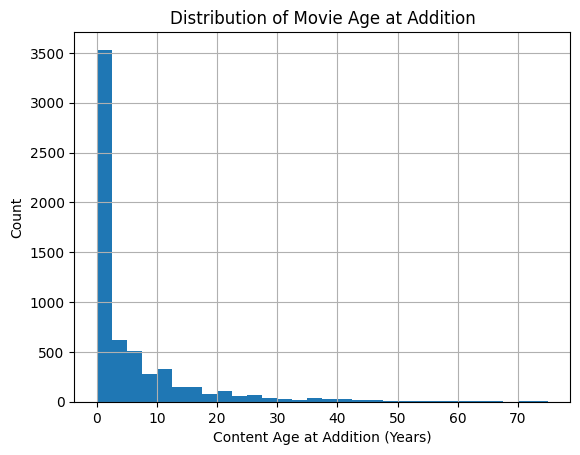

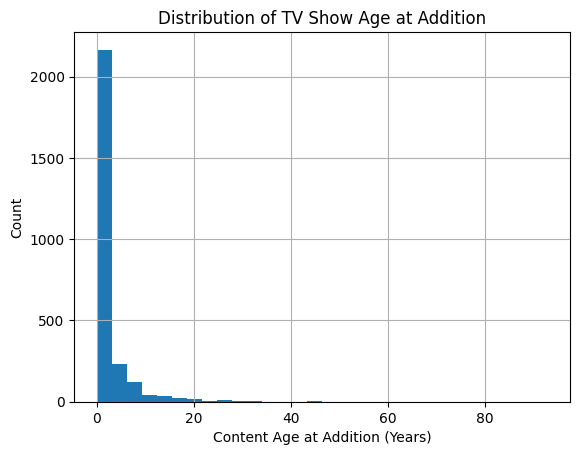

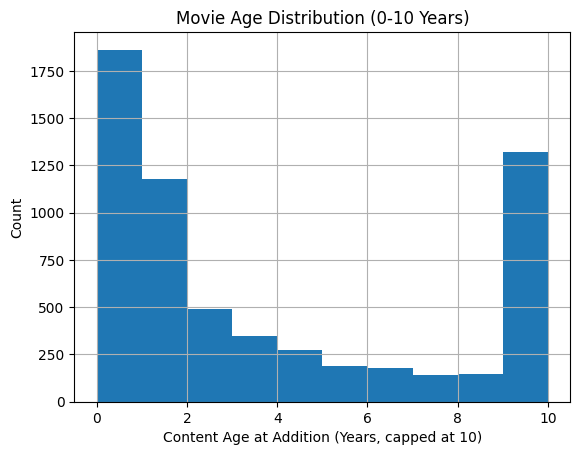

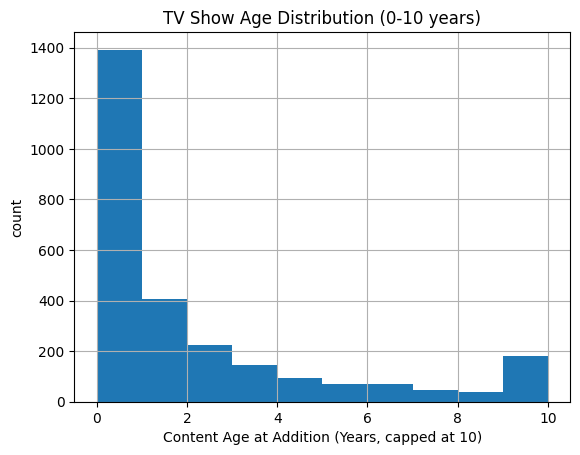

In [33]:
#5.2.2    Content Distribution by type and year_added (Visualization)

import matplotlib.pyplot as plt

plt.figure()                #-- create a new figure for movies
df[df['type'] == 'Movie']['content_age_at_add'].hist(bins=30)
plt.xlabel('Content Age at Addition (Years)')
plt.ylabel('Count')
plt.title('Distribution of Movie Age at Addition')
plt.show()

plt.figure()        #-- create a new figure for TV shows
df[df['type'] == 'TV Show']['content_age_at_add'].hist(bins=30)
plt.xlabel('Content Age at Addition (Years)')
plt.ylabel('Count')
plt.title('Distribution of TV Show Age at Addition')
plt.show()

plt.figure()            #-- create a new figure for movies with age capped at 10 years
df[df['type']=='Movie']['content_age_at_add'].clip(upper=10).hist(bins=10)
plt.xlabel("Content Age at Addition (Years, capped at 10)")
plt.ylabel("Count")
plt.title("Movie Age Distribution (0-10 Years)")
plt.show()

plt.figure()            #-- create a visual for TV shows with age capped at 10 years
df[df['type'] == 'TV Show']['content_age_at_add'].clip(upper=10).hist(bins=10)
plt.xlabel('Content Age at Addition (Years, capped at 10)')
plt.ylabel('count')
plt.title('TV Show Age Distribution (0-10 years)')
plt.show()

In [34]:
# 5.3.1   Content Distribution by Country
df_country = df.copy()
df_country['country'] = df_country['country'].str.split(',')
df_country = df_country.explode('country')
df_country['country'] = df_country['country'].str.strip()
country_counts = df_country['country'].value_counts()
print(country_counts.head(20))

print(df_country['country'].nunique())
print(df_country['country'].str.contains('Unknown', na=False).sum())
pd.set_option('display.max_rows', None)
print(df_country['country'].value_counts())
pd.reset_option('display.max_rows')
country_percent = country_counts / country_counts.sum() * 100
print(country_percent.head(10))

country
United States     3690
India             1045
Unknown            830
United Kingdom     806
Canada             445
France             393
Japan              318
Spain              232
South Korea        232
Germany            226
Mexico             169
China              162
Australia          160
Egypt              117
Turkey             113
Hong Kong          105
Nigeria            103
Italy              100
Brazil              97
Argentina           91
Name: count, dtype: int64
124
830
country
United States           3690
India                   1045
Unknown                  830
United Kingdom           806
Canada                   445
France                   393
Japan                    318
Spain                    232
South Korea              232
Germany                  226
Mexico                   169
China                    162
Australia                160
Egypt                    117
Turkey                   113
Hong Kong                105
Nigeria                  1

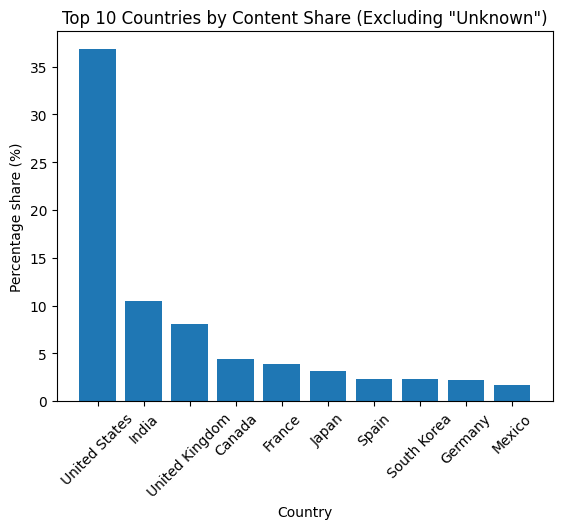

In [35]:
# 5.3.2    Content Distribution by Country (Visualization)

df_country_clean = df_country[df_country['country'] != 'Unknown']        #-- Exclude 'Unknown' from Top 10 values
country_counts_clean = df_country_clean['country'].value_counts()
country_percent_clean = country_counts_clean / country_counts_clean.sum() * 100
top_10 = country_percent_clean.head(10)         #-- Get top 10 countries by percentage share excluding 'Unknown' value

plt.figure()
plt.bar(top_10.index, top_10.values)
plt.xticks(rotation=45)
plt.xlabel('Country')
plt.ylabel('Percentage share (%)')
plt.title('Top 10 Countries by Content Share (Excluding "Unknown")')
plt.show()

**Markdown Distribution Insight**

1. The platform content spans 124 unique production countries, indicating strong global representation. However, production attribution is highly concentrated.

2. The United States accounts for approximately 34% of total country attributions, establishing it as the dominant production source. India follows at ~9.6%, highlighting its   strategic importance as a secondary content market.

3. The top five countries (United States, India, United Kingdom, Canada, and France) collectively contribute nearly 60% of all production attributions, suggesting structural concentration despite global diversity.

4. Approximately 9–10% of entries contain missing country metadata (“Unknown”), which represents a minor data limitation in geographic interpretation.

Overall, the platform demonstrates global reach but production concentration in a small group of major content-producing nations.

In [36]:
# 5.4.1    Content Distribution by Genre
df_genres = df.copy()
df_genres['genres'] = df_genres['genres'].str.split(',')
df_genres = df_genres.explode('genres')
df_genres['genres'] = df_genres['genres'].str.strip().str.title()        #-- Standardize genre names

df_genres_mapping = {           #-- Mapping of original genres to cleaned genres
    'Dramas': 'Drama',
    'Comedies': 'Comedy',
    'Action & Adventure': 'Action',
    'Documentaries': 'Documentary',
    'Children & Family Movies': 'Children & Family',
    'Thrillers': 'Thriller',
    'Horror Movies': 'Horror',
    'Sci-Fi & Fantasy': 'Sci-Fi',
    'Romantic Movies': 'Romance',
    'TV Dramas': 'TV Drama',
    'TV Comedies': 'TV Comedy',
    'TV Action & Adventure': 'TV Action & Adventure',
    'TV Documentaries': 'TV Documentary',
    'TV Thrillers': 'TV Thriller',
    'TV Horror': 'TV Horror'
}

df_genres['genres'] = df_genres['genres'].replace(df_genres_mapping)

genre_counts = df_genres['genres'].value_counts()
pd.set_option('display.max_rows', None)
print(df_genres['genres'].value_counts())
genres_percent = genre_counts / genre_counts.sum() * 100
print(genres_percent)
pd.reset_option('display.max_rows')

print(df_genres['genres'].nunique())

df_genres = df_genres.reset_index(drop=True)
genre_type_table = pd.crosstab(df_genres['genres'], df_genres['type'])

pd.set_option('display.max_rows', None)
print(genre_type_table.head(42))
pd.reset_option('display.max_rows')

genres
International Movies            2752
Drama                           2426
Comedy                          1673
International Tv Shows          1350
Documentary                      869
Action                           860
Tv Dramas                        762
Independent Movies               755
Children & Family                641
Romance                          617
Tv Comedies                      581
Thriller                         577
Crime Tv Shows                   470
Kids' Tv                         451
Docuseries                       395
Music & Musicals                 375
Romantic Tv Shows                370
Horror                           358
Stand-Up Comedy                  343
Reality Tv                       255
British Tv Shows                 253
Sci-Fi                           244
Sports Movies                    219
Anime Series                     176
Spanish-Language Tv Shows        174
Tv Action & Adventure            168
Korean Tv Shows                

In [37]:
# 5.4.2     Genre Dominance by Type (Movies vs TV Shows)

df_genres_clean = df_genres.copy()
df_genres_clean.loc[
    (df_genres_clean['type'] == 'TV Show') & 
    (df_genres_clean['genres'] == 'Action'),
    'genres'
] = 'Tv Action & Adventure'

df_genres_clean.loc[
    (df_genres_clean['type'] == 'TV Show') & 
    (df_genres_clean['genres'] == 'Horror'),
    'genres'
] = 'Tv Horror'

df_genres_clean.loc[
    (df_genres_clean['type'] == 'TV Show') &
    (df_genres_clean['genres'] == 'Sci-Fi'),
    'genres'
  ] = 'Tv Sci-Fi & Fantasy'

df_genres_clean = df_genres_clean.reset_index(drop=True)

print(df_genres_clean['genres'].nunique())

movie_genres = df_genres_clean[df_genres_clean['type'] == 'Movie']      #-- Filter for movies only
movie_genres = movie_genres['genres'].value_counts()        #-- Get genre counts for movies
movie_percent = movie_genres / movie_genres.sum() * 100     #-- Calculate percentage share of each genre within movies
tv_genres = df_genres_clean[df_genres_clean['type'] == 'TV Show']     #-- Filter for TV shows only
tv_genres = tv_genres['genres'].value_counts()          #-- Get genre counts for TV shows
tv_percent = tv_genres / tv_genres.sum() * 100         #-- Calculate percentage share of each genre within TV shows


print(tv_genres)
print(movie_genres)
print(tv_percent)
print(movie_percent)

42
genres
International Tv Shows          1350
Tv Dramas                        762
Tv Comedies                      581
Crime Tv Shows                   470
Kids' Tv                         451
Docuseries                       395
Romantic Tv Shows                370
Reality Tv                       255
British Tv Shows                 253
Anime Series                     176
Spanish-Language Tv Shows        174
Tv Action & Adventure            169
Korean Tv Shows                  151
Tv Mysteries                      98
Science & Nature Tv               92
Tv Sci-Fi & Fantasy               85
Tv Horror                         76
Teen Tv Shows                     69
Tv Thrillers                      57
Stand-Up Comedy & Talk Shows      56
Classic & Cult Tv                 28
Tv Shows                          16
Name: count, dtype: int64
genres
International Movies    2752
Drama                   2426
Comedy                  1673
Documentary              869
Action                   85

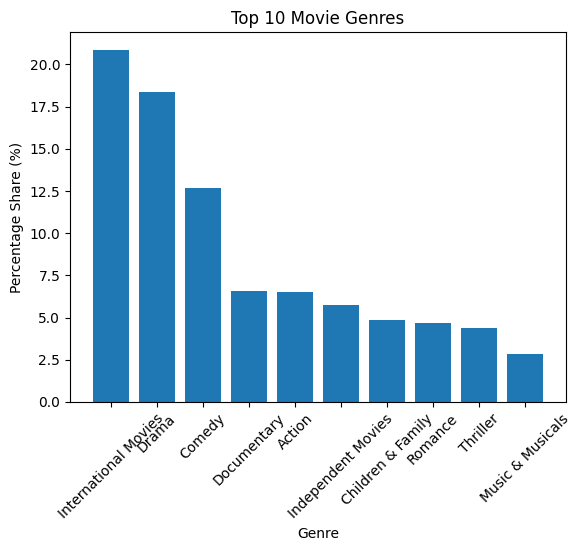

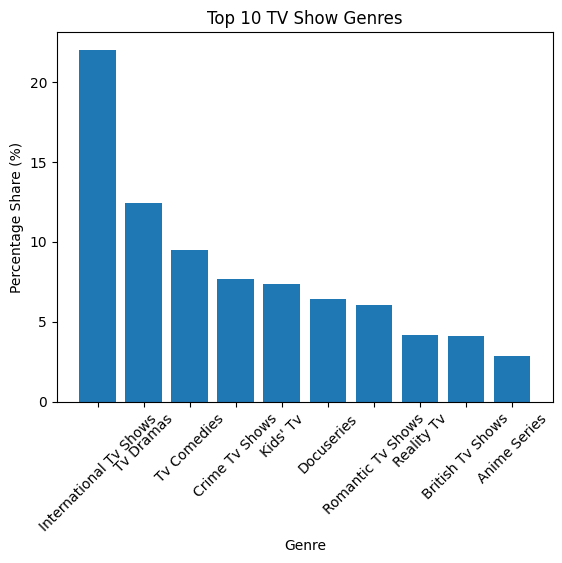

In [38]:
# 5.4.3   Genre Distribution by Type (Visualization)

movie_genres = df_genres_clean[df_genres_clean['type'] == 'Movie']      #-- Filter for movies only
movie_counts = movie_genres['genres'].value_counts()
movie_percent = (movie_counts / movie_counts.sum()) * 100

top_10_movies = movie_percent.head(10)

plt.figure()
plt.bar(top_10_movies.index, top_10_movies.values)
plt.xticks(rotation=45)
plt.xlabel("Genre")
plt.ylabel("Percentage Share (%)")
plt.title("Top 10 Movie Genres")
plt.show()

tv_genres = df_genres_clean[df_genres_clean['type'] == 'TV Show']       #-- Filter for TV shows only
tv_counts = tv_genres['genres'].value_counts()
tv_percent = (tv_counts / tv_counts.sum()) * 100

top_10_tv = tv_percent.head(10)

plt.figure()
plt.bar(top_10_tv.index, top_10_tv.values)
plt.xticks(rotation=45)
plt.xlabel("Genre")
plt.ylabel("Percentage Share (%)")
plt.title("Top 10 TV Show Genres")
plt.show()

**Genre Dominance by Content Type**

**TV Show Genre Distribution**

1. The TV catalog is heavily dominated by internationally oriented serialized content.

2. International TV Shows (22.0%) represent the largest share, indicating a strong focus on globally diverse television programming.

3. TV Dramas (12.4%) and TV Comedies (9.5%) follow, reinforcing the platform’s emphasis on narrative-driven and episodic entertainment.

4. Crime and Kids’ content also hold significant presence (~7% each), suggesting balanced targeting of adult and family audiences.

5. Docuseries (6.4%) and Romantic TV Shows (6.0%) indicate steady demand for non-fiction storytelling and relationship-driven content.

**Key Insight:**

1. TV content strategy appears strongly aligned with:

2. Global audience targeting

3. Serialized engagement

4. Retention-driven programming

5. The dominance of “International TV Shows” suggests an aggressive expansion into non-domestic television markets.

**Movie Genre Distribution**

1. Movie catalog composition reflects a hybrid mix of international diversity and traditional cinematic categories.

2. International Movies (20.9%) lead the category, closely followed by Drama (18.4%).

3. Comedy (12.7%) ranks third, highlighting continued demand for light entertainment.

4. Documentaries (6.6%) and Action (6.5%) demonstrate balanced genre diversification.

5. Independent Movies (5.7%) indicate support for non-mainstream cinema.

**Key Insight:**

1. Movie content strategy emphasizes:

2. International diversification

3. Emotion-driven storytelling (Drama dominance)

4. Balanced commercial genres (Comedy, Action)

5. Strong long-tail category support (Independent, Documentary)

6. Unlike TV shows, movie distribution appears less retention-focused and more catalog-expansion driven.

**Structural Observation:**

Both Movies and TV Shows demonstrate strong international orientation (~21–22%), indicating a platform-wide globalization strategy.

**However:**

1. TV content leans toward serialized and episodic storytelling.

2. Movie content leans toward traditional cinematic genres with broader thematic distribution.

**Final Conclusion**

1. The platform exhibits a dual content strategy:

2. TV Shows are structured to maximize retention and global engagement through international and serialized storytelling.

3. Movies are structured to expand catalog depth with a strong mix of international, dramatic, and commercial genres.

**This reflects a mature streaming model balancing:**

1. Engagement

2. Diversity

3. Catalog expansion

4. Global market penetration

In [39]:
# 5.4.4    Genre Distribution by Country (Movies Only)
movie_genres_country = df_genres_clean[df_genres_clean['type'] == 'Movie']       #-- Filter for movies only
movie_country_genres_table = pd.crosstab(movie_genres_country['country'], movie_genres_country['genres'])       #-- Create crosstab of country vs genres for movies

top_movie_countries = country_counts_clean.head(5).index            #-- Get top 5 countries by content share (excluding 'Unknown')
movie_country_genres_table = movie_country_genres_table.loc[top_movie_countries]        #-- Filter crosstab to include only top 5 countries
print(movie_country_genres_table)

movie_data = df_genres_clean[
    (df_genres_clean['type'] == 'Movie') &
(df_genres_clean['country'] != 'Unknown')].copy()         #-- Filter for movies only

movie_data = movie_data.reset_index(drop=True)        #-- Reset index after filtering
country_movie_counts = movie_data['country'].value_counts()                     #-- Get movie counts by country
country_movie_share = country_movie_counts / country_movie_counts.sum()         #-- Calculate relative share of movies by country

movie_country_genres = pd.crosstab(movie_data['country'], movie_data['genres'])        #-- Create crosstab of country vs genres for movies
genre_country_share = movie_country_genres.div(movie_country_genres.sum(axis=0), axis=1)       #-- Calculate relative share of each genre within each country

rsi_table = genre_country_share.div(country_movie_share, axis=0)       #-- Calculate Relative Strength Index (RSI) of genres by country
top10_countries = country_movie_counts.head(10).index
rsi_top10 = rsi_table.loc[top10_countries]        #-- Filter RSI table to include only top 10 countries

print(rsi_top10.round(2))                   #-- Print RSI values rounded to 2 decimal places for better readability

genre_totals = movie_country_genres.sum()       #-- Get total counts of each genre across all countries for reference
valid_genres = genre_totals[genre_totals > 0].index        #-- Define valid genres with at least 20 movies across all countries
rsi_filtered = rsi_top10[valid_genres]        #-- Filter RSI table to include only valid genres with sufficient data

genre_rsi_leaders = rsi_filtered.idxmax()       #-- Identify the country with the highest RSI for each genre (genre leaders)
genre_rsi_values = rsi_filtered.max()       #-- Get the corresponding RSI values for the genre leaders

result = pd.DataFrame({                     #-- Create a result dataframe to summarize the genre leaders and their RSI values
    'Top Country' :  genre_rsi_leaders,
    'RSI' : genre_rsi_values.round(2),
}).sort_values(by='RSI', ascending=False)

result['Total Genre Count'] = genre_totals[result.index]        #-- Add total genre counts to the result dataframe for reference

print(result.sort_values(by='RSI', ascending=False))

genres          Action  Anime Features  Children & Family  Classic Movies  \
country                                                                     
United States      249               1                272              61   
India              127               0                 18              11   
United Kingdom      19               0                  8               3   
Canada              12               0                 31               0   
France              12               0                  1               0   

genres          Comedy  Cult Movies  Documentary  Drama  Faith & Spirituality  \
country                                                                         
United States      524           39          411    592                    30   
India              307            5           19    619                     3   
United Kingdom      32            3           84     45                     0   
Canada              39            3           21     22

**Genre Leadership Insights (RSI-Based)**

**Volume ≠ Specialization**

1. The United States and India dominate total output, but rarely lead in RSI.
2. Large industries are diversified — specialization gets diluted.

**Clear Structural Leaders**

1. Japan → Anime (52.84), Action

2. UK → Documentary, Sports

3. Indonesia → Faith & Spirituality, Horror

4. Canada → Children & Family, Cult

5. 5Philippines → Romance

These are not random spikes — they reflect cultural or institutional alignment.

**Smaller Markets Show Sharper Identity**

1. Mid-sized countries often display higher RSI because their production ecosystems are more focused.

2. Specialization is stronger where scale is smaller.

**Two Patterns Emerge**

1. High RSI + Low Genre Volume → Niche dominance (e.g., Anime – Japan)

2. High RSI + High Genre Volume → Scalable leadership (e.g., Documentary – UK)

**Strategic Takeaway**

1. Global genre leadership is structural, not volume-driven.
2. Diversified markets dominate in scale.
3. Focused markets dominate in identity.

In [40]:
# 5.4.5    Genre Distribution by Country (TV Shows Only)
tv_genres_country = df_genres_clean[df_genres_clean['type'] == 'TV Show']       #-- Filter for TV shows only
tv_country_genres_table = pd.crosstab(tv_genres_country['country'], tv_genres_country['genres'])       #-- Create crosstab of country vs genres for TV shows

top_tv_countries = country_counts_clean.head(5).index            #-- Get top 5 countries by content share (excluding 'Unknown')
tv_country_genres_table = tv_country_genres_table.loc[top_tv_countries]        #-- Filter crosstab to include only top 5 countries
print(tv_country_genres_table)

tv_data = df_genres_clean[
    (df_genres_clean['type'] == 'TV Show') &
(df_genres_clean['country'] != 'Unknown')].copy()         #-- Filter for TV shows only

tv_data = tv_data.reset_index(drop=True)        #-- Reset index after filtering
country_tv_counts = tv_data['country'].value_counts()                     #-- Get TV show counts by country
country_tv_share = country_tv_counts / country_tv_counts.sum()         #-- Calculate relative share of TV shows by country

tv_country_genres = pd.crosstab(tv_data['country'], tv_data['genres'])        #-- Create crosstab of country vs genres for TV shows
genre_country_share = tv_country_genres.div(tv_country_genres.sum(axis=0), axis=1)       #-- Calculate relative share of each genre within each country

rsi_table = genre_country_share.div(country_tv_share, axis=0)       #-- Calculate Relative Strength Index (RSI) of genres by country
top10_countries = country_tv_counts.head(10).index
rsi_top10 = rsi_table.loc[top10_countries]        #-- Filter RSI table to include only top 10 countries

print(rsi_top10.round(2))                   #-- Print RSI values rounded to 2 decimal places for better readability

genre_totals = tv_country_genres.sum()       #-- Get total counts of each genre across all countries for reference
valid_genres = genre_totals[genre_totals > 0].index        #-- Define valid genres with at least 20 movies across all countries
rsi_filtered = rsi_top10[valid_genres]        #-- Filter RSI table to include only valid genres with sufficient data

genre_rsi_leaders = rsi_filtered.idxmax()       #-- Identify the country with the highest RSI for each genre (genre leaders)
genre_rsi_values = rsi_filtered.max()       #-- Get the corresponding RSI values for the genre leaders

result = pd.DataFrame({                     #-- Create a result dataframe to summarize the genre leaders and their RSI values
    'Top Country' :  genre_rsi_leaders,
    'RSI' : genre_rsi_values.round(2),
}).sort_values(by='RSI', ascending=False)

result['Total Genre Count'] = genre_totals[result.index]        #-- Add total genre counts to the result dataframe for reference

print(result.sort_values(by='RSI', ascending=False))

genres          Anime Series  British Tv Shows  Classic & Cult Tv  \
country                                                             
United States              6                 5                 13   
India                      0                 2                  0   
United Kingdom             0               196                  6   
Canada                     0                 0                  1   
France                     0                 0                  0   

genres          Crime Tv Shows  Docuseries  International Tv Shows  Kids' Tv  \
country                                                                        
United States              111         173                      27       146   
India                        8           8                      65        10   
United Kingdom              38          78                     112        22   
Canada                       9           8                      19        20   
France                      14      

**TV Genre Insights & Movie Comparison**

**TV Genre Leadership**

• TV shows display strong regional and language-based specialization.

**High RSI leaders are culturally anchored:**

• Japan → Anime Series

• South Korea → Korean TV Shows

• Mexico → Spanish-Language TV, Crime

• UK → British TV, Docuseries

• USA → Reality, Sci-Fi, Talk Shows

• Unlike films, TV ecosystems are deeply tied to domestic identity and format traditions. Language-driven genres show the highest specialization intensity, indicating that TV production remains structurally local even in a global streaming environment.

• Large markets like the U.S. demonstrate scalable multi-genre strength, while mid-sized markets show sharper niche positioning.

**TV vs Movies: Structural Contrast**

• Movies exhibit broader diversification and lower specialization volatility. Large producers (USA, India) dominate in volume but not in extreme genre concentration.

• TV shows, in contrast, show higher RSI spikes and stronger cultural clustering.

**Core distinction:**

• Movies → Globally diversified production

• TV → Regionally concentrated specialization

• This suggests that film industries scale across genres, while television ecosystems reinforce cultural identity and domestic storytelling strength.